In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions.categorical import Categorical
import gymnasium as gym
import ale_py
import numpy as np
import matplotlib.pyplot as plt
from gymnasium.wrappers import AtariPreprocessing, FrameStackObservation

gym.register_envs(ale_py)

# Step 1: Rebuild the agent architecture (NatureCNN)
class Agent(nn.Module):
    def __init__(self, action_dim=6):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(4, 32, 8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, stride=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(3136, 512),
            nn.ReLU(),
        )
        self.actor = nn.Linear(512, action_dim)
        self.critic = nn.Linear(512, 1)

    def get_action_and_value(self, obs):
        features = self.network(obs)
        logits = self.actor(features)
        dist = Categorical(logits=logits)
        action = dist.sample()
        return action, logits

# Step 2: Load the trained model
agent = Agent()
checkpoint = torch.load('/kaggle/input/datasets/yusufhilalll/naturecnn-final/final_model_Seed4.pt',
                        map_location='cpu')
agent.load_state_dict(checkpoint['agent'])
agent.eval()
print("Model loaded")

# Step 3: Grad-CAM implementation
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, obs):
        self.model.zero_grad()
        features = self.model.network(obs)
        logits = self.model.actor(features)
        action = logits.argmax(dim=1)
        logits[0, action].backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=(84, 84), mode='bilinear', align_corners=False)
        cam = cam.squeeze().numpy()
        if cam.max() > 0:
            cam = cam / cam.max()
        return cam, action.item()

gradcam = GradCAM(agent, agent.network[4])

action_meanings = ['NOOP', 'FIRE', 'RIGHT', 'LEFT', 'RIGHTFIRE', 'LEFTFIRE']

Model loaded


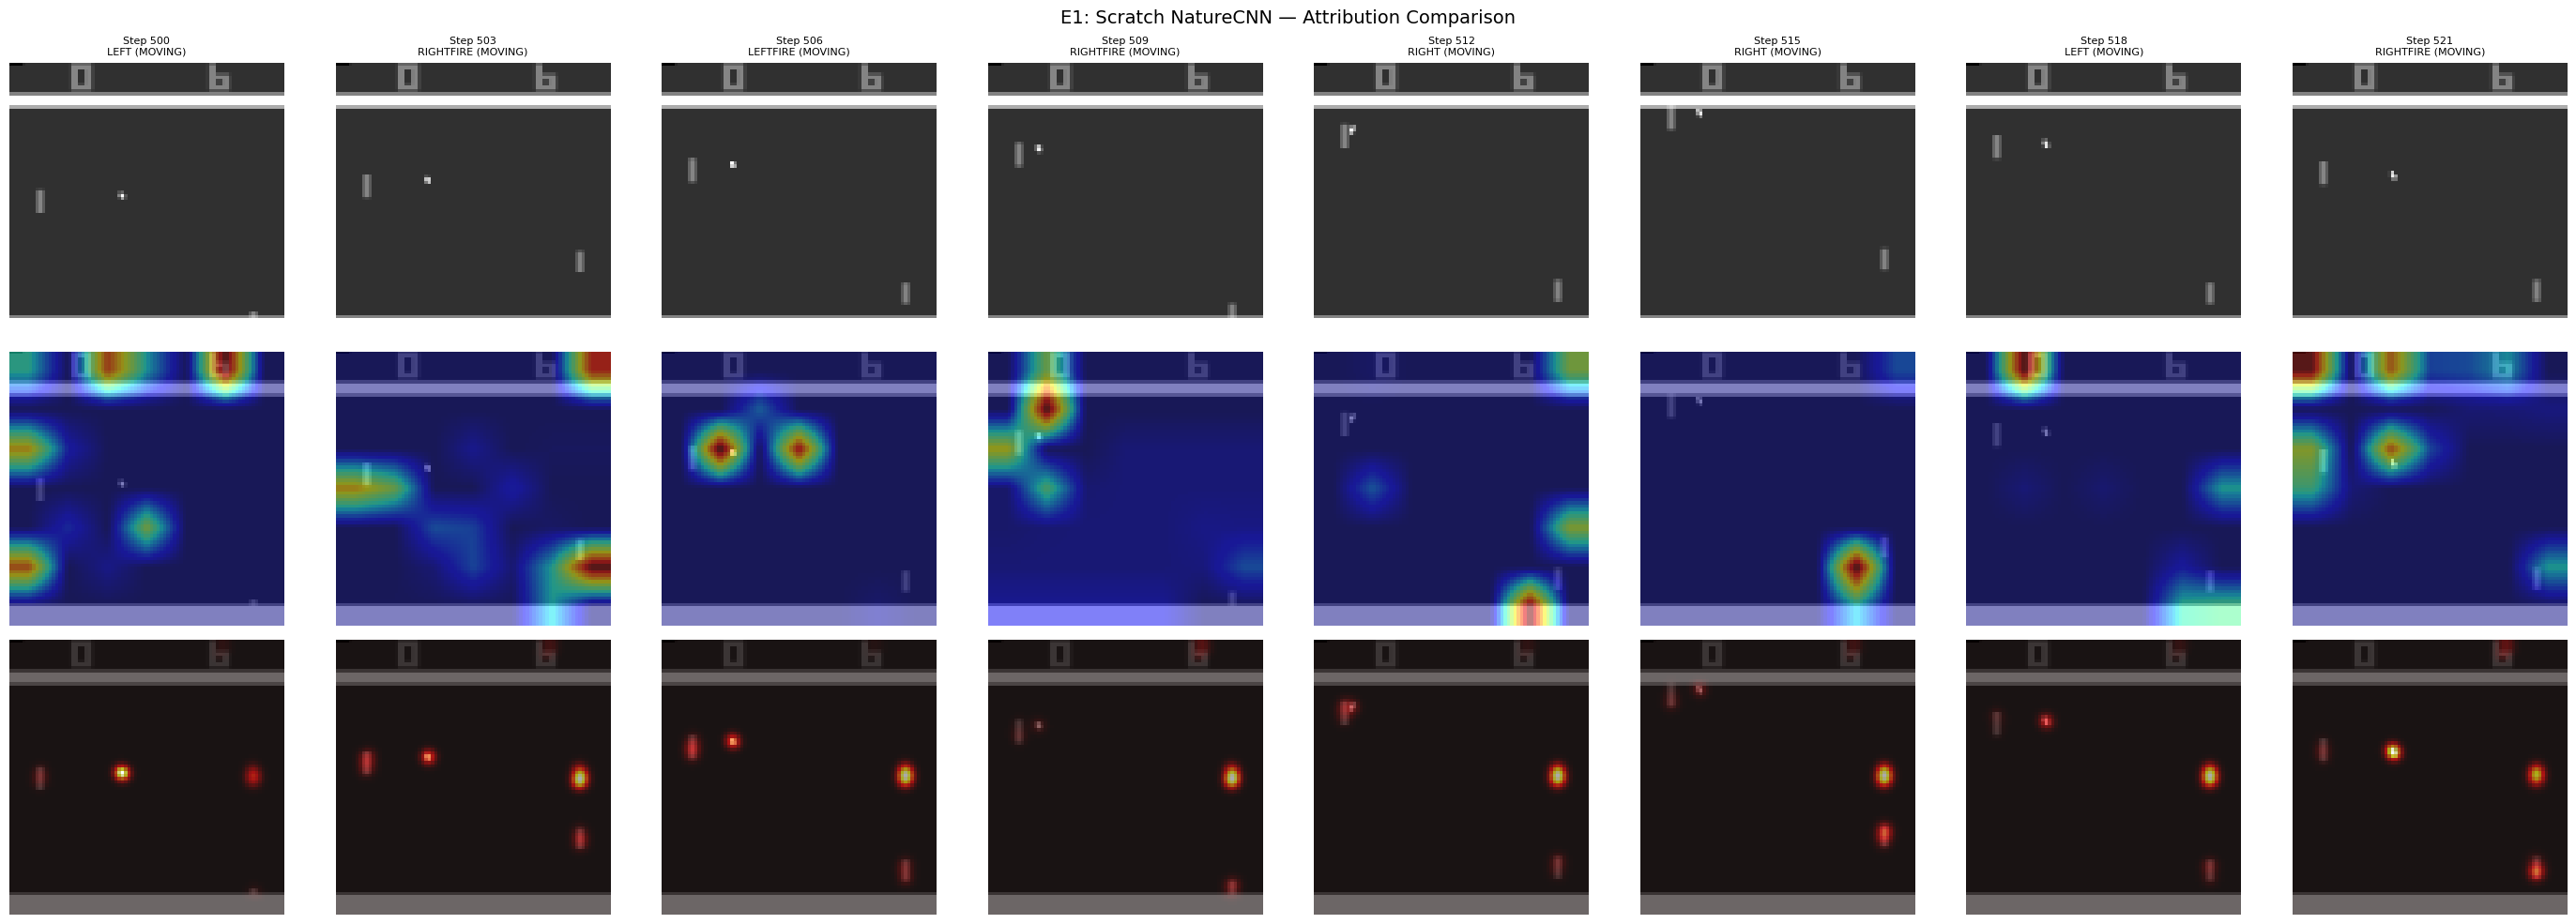

Done!


In [6]:
class IntegratedGradients:
    def __init__(self, model, n_steps=100):
        self.model = model
        self.n_steps = n_steps
    
    def generate(self, obs, baseline=None):
        if baseline is None:
            baseline = torch.zeros_like(obs)
        
        total_grads = torch.zeros_like(obs)
        
        with torch.no_grad():
            real_features = self.model.network(obs)
            real_logits = self.model.actor(real_features)
            action = real_logits.argmax(dim=1).item()
        
        for step in range(self.n_steps):
            alpha = step / self.n_steps
            interpolated = baseline + alpha * (obs - baseline)
            interpolated = interpolated.clone().detach().requires_grad_(True)
            
            self.model.zero_grad()
            features = self.model.network(interpolated)
            logits = self.model.actor(features)
            logits[0, action].backward()
            total_grads += interpolated.grad
        
        avg_grads = total_grads / self.n_steps
        attribution = (obs - baseline) * avg_grads
        
        attr_map = attribution.squeeze()[3].detach().numpy()
        attr_map = np.abs(attr_map)
        
        from scipy.ndimage import gaussian_filter
        attr_map = gaussian_filter(attr_map, sigma=1.5)
        
        # Only keep top 20% of attributions
        threshold = np.percentile(attr_map, 80)
        attr_map[attr_map < threshold] = 0
        
        if attr_map.max() > 0:
            attr_map = attr_map / attr_map.max()
        
        return attr_map, action

# Create a baseline from an empty game frame (no ball, no action)
env_baseline = gym.make("PongNoFrameskip-v4")
env_baseline = AtariPreprocessing(env_baseline, frame_skip=4, screen_size=84,
                                   grayscale_obs=True, scale_obs=False)
env_baseline = FrameStackObservation(env_baseline, 4)
baseline_obs, _ = env_baseline.reset(seed=99)
# Just sit still for a few frames to get a clean background
for _ in range(5):
    baseline_obs, _, _, _, _ = env_baseline.step(0)  # NOOP
baseline_tensor = torch.tensor(np.array(baseline_obs), dtype=torch.float32).unsqueeze(0)
env_baseline.close()

ig = IntegratedGradients(agent, n_steps=100)

# Collect frames
env = gym.make("PongNoFrameskip-v4")
env = AtariPreprocessing(env, frame_skip=4, screen_size=84,
                         grayscale_obs=True, scale_obs=False)
env = FrameStackObservation(env, 4)

frames_to_analyze = []
obs, _ = env.reset(seed=2)
last_saved_step = -20

for step in range(3000):
    obs_tensor = torch.tensor(np.array(obs), dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        action, logits = agent.get_action_and_value(obs_tensor)
    
    act = action.item()
    obs, reward, term, trunc, info = env.step(act)
    
    if step < 500 or step - last_saved_step < 3:
        if term or trunc:
            obs, _ = env.reset()
        continue
    
    label = None
    if reward == 1.0:
        label = "SCORED"
    elif reward == -1.0:
        label = "CONCEDED"
    elif act in [2, 3, 4, 5]:
        label = "MOVING"
    
    if label and len(frames_to_analyze) < 8:
        frames_to_analyze.append((np.array(obs).copy(), step, act, label))
        last_saved_step = step
    
    if term or trunc:
        obs, _ = env.reset()

env.close()

# Generate and plot
n_frames = min(len(frames_to_analyze), 8)
fig, axes = plt.subplots(3, n_frames, figsize=(3.5*n_frames, 10))

for i in range(n_frames):
    frame_stack, step, act, label = frames_to_analyze[i]
    obs_tensor = torch.tensor(frame_stack, dtype=torch.float32).unsqueeze(0)
    
    # Grad-CAM
    obs_tensor.requires_grad_(True)
    cam, _ = gradcam.generate(obs_tensor)
    
    # Integrated Gradients
    obs_tensor2 = torch.tensor(frame_stack, dtype=torch.float32).unsqueeze(0)
    ig_map, _ = ig.generate(obs_tensor2, baseline=baseline_tensor)
    
    # Row 1: Raw frame
    axes[0, i].imshow(frame_stack[3], cmap='gray')
    axes[0, i].set_title(f'Step {step}\n{action_meanings[act]} ({label})', fontsize=8)
    axes[0, i].axis('off')
    
    # Row 2: Grad-CAM
    axes[1, i].imshow(frame_stack[3], cmap='gray')
    axes[1, i].imshow(cam, cmap='jet', alpha=0.5)
    axes[1, i].axis('off')
    
    # Row 3: Integrated Gradients
    axes[2, i].imshow(frame_stack[3], cmap='gray')
    axes[2, i].imshow(ig_map, cmap='hot', alpha=0.6)
    axes[2, i].axis('off')

axes[0, 0].set_ylabel('Raw Frame', fontsize=11)
axes[1, 0].set_ylabel('Grad-CAM', fontsize=11)
axes[2, 0].set_ylabel('Integrated\nGradients', fontsize=11)

plt.suptitle('E1: Scratch NatureCNN — Attribution Comparison', fontsize=14)
plt.tight_layout()
plt.savefig('e1_gradcam_vs_ig.png', dpi=150, bbox_inches='tight')
plt.show()
print("Done!")

Model loaded
  500/3000
  1000/3000
  1500/3000
  2000/3000
  2500/3000
  3000/3000
Dataset: (3000, 4, 84, 84), Ball positions: (3000, 2)
Extracting features...
Features shape: (3000, 512)
Random baseline error: 21.64 pixels
  Epoch 25: train=24.10px, test=24.46px
  Epoch 50: train=18.15px, test=18.82px
  Epoch 75: train=15.75px, test=16.29px
  Epoch 100: train=14.17px, test=14.83px

Final test error: 14.83 pixels
Random baseline: 21.64 pixels
Improvement: 31.5%


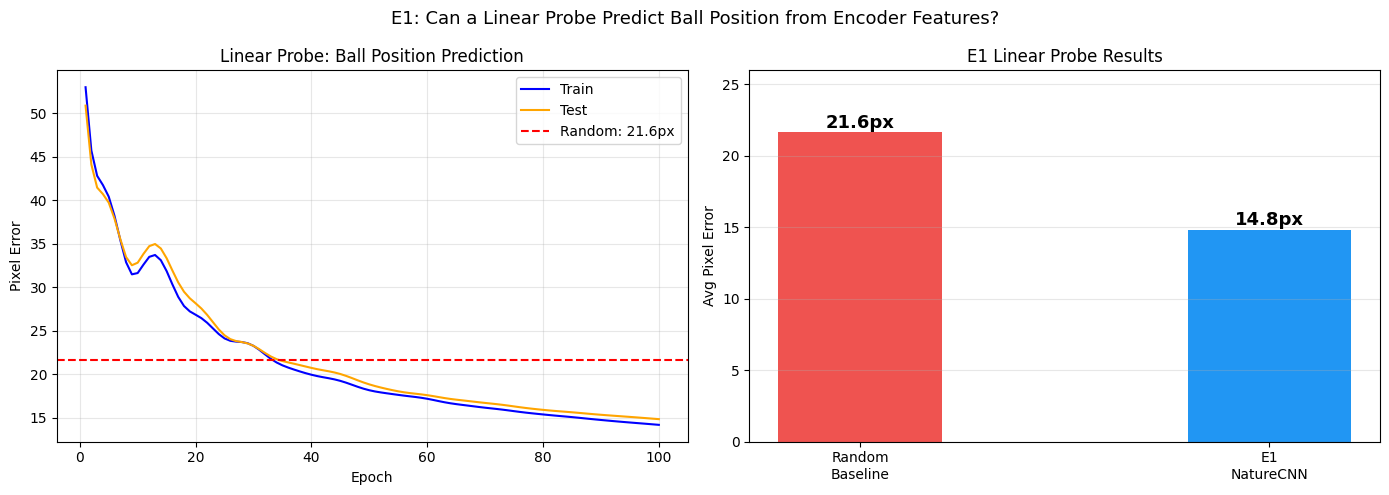

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import gymnasium as gym
import ale_py
import numpy as np
import matplotlib.pyplot as plt
from gymnasium.wrappers import AtariPreprocessing, FrameStackObservation
from scipy import ndimage
from sklearn.model_selection import train_test_split

gym.register_envs(ale_py)

# ---- Rebuild and load E1 agent ----
class Agent(nn.Module):
    def __init__(self, action_dim=6):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv2d(4, 32, 8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, stride=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(3136, 512),
            nn.ReLU(),
        )
        self.actor = nn.Linear(512, action_dim)
        self.critic = nn.Linear(512, 1)

agent = Agent()
checkpoint = torch.load('/kaggle/input/datasets/yusufhilalll/naturecnn-final/final_model_Seed4.pt',
                        map_location='cpu')
agent.load_state_dict(checkpoint['agent'])
agent.eval()
print("Model loaded")

# ---- Step 1: Find ball position in a frame ----
def find_ball_position(frame):
    """Find the ball (small bright cluster) in an 84x84 grayscale frame"""
    binary = (frame > 200).astype(np.uint8)
    labeled, n = ndimage.label(binary)
    if n == 0:
        return None
    # Ball is a small bright object (not the paddles which are taller)
    best_pos, best_size = None, 999
    for lid in range(1, n + 1):
        ys, xs = np.where(labeled == lid)
        size = len(ys)
        height = ys.max() - ys.min() + 1
        width = xs.max() - xs.min() + 1
        # Ball is roughly square and small, paddles are tall and thin
        if 1 <= size <= 12 and height <= 4 and width <= 4:
            if size < best_size:
                best_size = size
                best_pos = (float(ys.mean()), float(xs.mean()))
    return best_pos

# ---- Step 2: Collect frames with ball positions ----
print("Collecting frames...")
env = gym.make("PongNoFrameskip-v4")
env = AtariPreprocessing(env, frame_skip=4, screen_size=84,
                         grayscale_obs=True, scale_obs=False)
env = FrameStackObservation(env, 4)

observations = []
positions = []
obs, _ = env.reset(seed=42)

while len(observations) < 3000:
    obs, _, term, trunc, _ = env.step(env.action_space.sample())
    if term or trunc:
        obs, _ = env.reset()
        continue
    
    # Find ball in the most recent frame (frame 3)
    pos = find_ball_position(np.array(obs)[3])
    if pos is not None:
        observations.append(np.array(obs))
        positions.append(pos)
        if len(observations) % 500 == 0:
            print(f"  {len(observations)}/3000")

env.close()

obs_data = np.array(observations)
ball_data = np.array(positions, dtype=np.float32)
print(f"Dataset: {obs_data.shape}, Ball positions: {ball_data.shape}")

# ---- Step 3: Extract features from the encoder ----
print("Extracting features...")
features = []
with torch.no_grad():
    for i in range(0, len(obs_data), 64):
        batch = torch.tensor(obs_data[i:i+64], dtype=torch.float32)
        feat = agent.network(batch)  # (batch, 512)
        features.append(feat.cpu())

features = torch.cat(features).numpy()
print(f"Features shape: {features.shape}")

# ---- Step 4: Train linear probe ----
# Random baseline: always predict the mean position
mean_pos = ball_data.mean(axis=0)
random_baseline = np.sqrt(((ball_data - mean_pos) ** 2).sum(axis=1)).mean()
print(f"Random baseline error: {random_baseline:.2f} pixels")

X_train, X_test, y_train, y_test = train_test_split(
    features, ball_data, test_size=0.2, random_state=42)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

probe = nn.Linear(512, 2)  # predict (y, x) of ball
optimizer = torch.optim.Adam(probe.parameters(), lr=1e-3)

train_errors = []
test_errors = []

for epoch in range(100):
    # Train
    probe.train()
    pred = probe(X_train_t)
    loss = F.mse_loss(pred, y_train_t)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    # Evaluate
    probe.eval()
    with torch.no_grad():
        test_pred = probe(X_test_t)
        test_err = torch.sqrt(((test_pred - y_test_t) ** 2).sum(1)).mean().item()
        train_pred = probe(X_train_t)
        train_err = torch.sqrt(((train_pred - y_train_t) ** 2).sum(1)).mean().item()
    
    train_errors.append(train_err)
    test_errors.append(test_err)
    
    if (epoch + 1) % 25 == 0:
        print(f"  Epoch {epoch+1}: train={train_err:.2f}px, test={test_err:.2f}px")

print(f"\nFinal test error: {test_errors[-1]:.2f} pixels")
print(f"Random baseline: {random_baseline:.2f} pixels")
print(f"Improvement: {(1 - test_errors[-1]/random_baseline)*100:.1f}%")

# ---- Step 5: Plot results ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Learning curve
axes[0].plot(range(1, 101), train_errors, label='Train', color='blue')
axes[0].plot(range(1, 101), test_errors, label='Test', color='orange')
axes[0].axhline(random_baseline, color='red', ls='--', label=f'Random: {random_baseline:.1f}px')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Pixel Error')
axes[0].set_title('Linear Probe: Ball Position Prediction')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bar chart
names = ['Random\nBaseline', 'E1\nNatureCNN']
vals = [random_baseline, test_errors[-1]]
colors = ['#EF5350', '#2196F3']
bars = axes[1].bar(names, vals, color=colors, width=0.4)
for b, v in zip(bars, vals):
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
                 f'{v:.1f}px', ha='center', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Avg Pixel Error')
axes[1].set_title('E1 Linear Probe Results')
axes[1].set_ylim(0, max(vals) * 1.2)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('E1: Can a Linear Probe Predict Ball Position from Encoder Features?', fontsize=13)
plt.tight_layout()
plt.savefig('e1_linear_probe.png', dpi=150, bbox_inches='tight')
plt.show()